In [ ]:

import logging
from pathlib import Path

import numpy as np
import polars as pl
import pandas as pd
# from decimal import Decimal
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

from typing import Optional, Tuple



In [2]:
# ============================================================================
# [START] - Polars Display Configurations
# ============================================================================

pl.Config.set_tbl_rows(1000)      # show up to 100 rows
pl.Config.set_tbl_cols(50)       # show up to 50 columns
# pl.Config.set_tbl_width_chars(0) # 0 = no width limit
pl.Config.set_tbl_hide_dataframe_shape(False)  # keep shape info

# [ DEFAULT DECIMAL DISPLAY ]
# # Option 1: Set display precision globally
# pl.Config.set_fmt_float("full")

# Option 2: Set specific decimal places
# pl.Config.set_float_precision(7)

# # Option 3: Check individual values
# print(result["price_decimal"][7])  # Will show: 0.0070995

# ============================================================================
# [END] - Polars Display Configurations
# ============================================================================

polars.config.Config

In [3]:

class AvailableDatasets:
    """Available Datasets, returns request ID"""

    FULL_YEAR_2024__CME_JPY_V: str = "GLBX-20251028-HAE9P7SP3U"
    FULL_YEAR_2023__CME_JPY_V: str = "GLBX-20251116-MJ5JKQA9A4"
    FULL_YEAR_2022__CME_JPY_V: str = "GLBX-20251115-DJHUGKSLWB"


In [4]:

# WORKING DIRECTORY
MAIN_DIR = Path("/Users/number6/Projects/Bimini/")

# HISTORICAL DATA
HISTORICAL_DATA = MAIN_DIR / "0_data" / "historical"

# IMPORT PATH
PARQUET_DIR = HISTORICAL_DATA / "parquet"

# EXPORT PATH
EXPORT_DIR = MAIN_DIR / "journal_results"


In [5]:


"""

?

"""



TICK_SIZE = 0.00001




# Convert START_DATE and END_DATE to nanosecond epochs (integers)
START_DATE_NS = int(
    datetime(
        year=2022,
        month=10,
        day=27,
        hour=8,
        minute=0,
        second=0,
        tzinfo=timezone.utc,
    ).timestamp() * 1e9
)

END_DATE_NS = int(
    datetime(
        year=2022,
        month=11,
        day=14,
        hour=18,
        minute=0,
        second=0,
        tzinfo=timezone.utc,
    ).timestamp() * 1e9
)


hrf_start_dt = datetime.fromtimestamp(START_DATE_NS / 1e9, tz=timezone.utc)
hrf_end_dt = datetime.fromtimestamp(END_DATE_NS / 1e9, tz=timezone.utc)

print("START_DATE_NS", hrf_start_dt.strftime("%Y-%m-%d %H:%M:%S %Z"))
print("END_DATE_NS", hrf_end_dt.strftime("%Y-%m-%d %H:%M:%S %Z"))


"""

Rolling average container

Container_Size > Search_Range

Thus only consider end time for each new interval of the rolling average that would be available in the time frame


"""



START_DATE_NS 2022-10-27 08:00:00 UTC
END_DATE_NS 2022-11-14 18:00:00 UTC


'\n\nRolling average container\n\nContainer_Size > Search_Range\n\nThus only consider end time for each new interval of the rolling average that would be available in the time frame\n\n\n'

In [6]:

BUCKET_DIR = Path("/Users/number6/Projects/Bimini/pool_vb100_fb30/2313_Nov_21_25/bucket/fixed/bucket_fixed_consolidated.parquet")

# Data files to glob for processing
BUCKET_DATA_GLOB = pl.scan_parquet(str(BUCKET_DIR))

# Schema? ...


In [7]:
VOLUME_BAR_DIR = Path("/Users/number6/Projects/Bimini/pool_vb100_fb30/2313_Nov_21_25/bucket/fixed/bucket_fixed_consolidated.parquet")

# Data files to glob for processing
VOLUME_BAR_DATA_GLOB = pl.scan_parquet(str(VOLUME_BAR_DIR))

# Schema? ...


In [8]:
"""

DATASET FILTERED FOR EVENT

VolumeBar, used for price plots(?)

"""


# event__vb_lf = (
#     VOLUME_BAR_DATA_GLOB
#     .filter(
#         (pl.col("end_ts_ns").dt.epoch(time_unit="ns") >= START_DATE_NS) & 
#         (pl.col("end_ts_ns").dt.epoch(time_unit="ns") <= END_DATE_NS)
#     )
#     .with_columns([
#         pl.from_epoch(pl.col("end_ts_ns"), time_unit="ns").alias("end_ts_ns"),
#     ])
# ).collect()


'\n\nDATASET FILTERED FOR EVENT\n\nVolumeBar, used for price plots(?)\n\n'

In [9]:
def plot_price_with_metrics(
    main_df: pl.DataFrame,
    main_ts_col: str,
    main_col: str,
    metrics_df: pl.DataFrame,
    metrics_ts_col: str,
    metric_cols: list[str],
    metric_labels: Optional[list[str]] = None,
    main_range: Tuple[Optional[float], Optional[float]] = (None, None),
    metric_range: Tuple[Optional[float], Optional[float]] = (None, None),
    main_range_padding: Tuple[float, float] = (0.0, 0.0),
    metric_range_padding: Tuple[float, float] = (0.0, 0.0),
    title: str = "Main Series vs. Metrics",
    main_label: str = "Main Series",
    main_symbol: str = "",
    main_symbol_prefix: bool = True,
    main_decimal_places: Optional[int] = None,
    show_calculation_guides: bool = True,
    step_lines: bool = True,
    event_a_col: str = "",
    event_a_label: str = "Event A",
    event_b_col: str = "",
    event_b_label: str = "Event B",
    show_time_labels: bool = True,
    rotate_time_labels: Optional[float] = None,
    time_label_interval_hours: Optional[int] = None,
    time_label_format: str = 'auto',
    time_label_max_count: Optional[int] = None,
    figsize: Tuple[int, int] = (16, 10),
) -> Tuple[plt.Figure, Tuple[plt.Axes, plt.Axes]]:
    """
    Plot a main time series with 1-4 metric time series on a dual-axis chart.
    
    Parameters
    ----------
    main_df : pl.DataFrame
        DataFrame containing main series data with nanosecond epoch timestamps.
    main_ts_col : str
        Column name for main series timestamps (nanosecond epoch).
    main_col : str
        Column name for main series values.
    metrics_df : pl.DataFrame
        DataFrame containing metric data with shared timestamps.
    metrics_ts_col : str
        Column name for metric timestamps (nanosecond epoch).
    metric_cols : list[str]
        List of 1-4 column names for metrics to plot.
    metric_labels : list[str], optional
        Display labels for metrics. Defaults to column names.
    main_range : tuple[float | None, float | None]
        Y-axis range for main series: (min, max). Use (None, None) for auto-calculation.
    metric_range : tuple[float | None, float | None]
        Y-axis range for metrics: (min, max). Use (None, None) for auto-calculation.
    main_range_padding : tuple[float, float]
        Absolute padding to add to main range: (lower_bound, upper_bound).
    metric_range_padding : tuple[float, float]
        Absolute padding to add to metric range: (lower_bound, upper_bound).
    title : str
        Chart title.
    main_label : str
        Label for main series in legend.
    main_symbol : str
        Symbol to display with main axis values (e.g., "$", "€", "¥"). Empty string for no symbol.
    main_symbol_prefix : bool
        If True, symbol appears before value. If False, symbol appears after value.
    main_decimal_places : int, optional
        Number of decimal places for main axis. None for auto-determination.
    show_calculation_guides : bool
        Whether to show calculation point markers and vertical interval lines.
    step_lines : bool
        If True, draw step function (horizontal lines held constant).
        If False, draw thin lines connecting calculation points.
    event_a_col : str
        Column name for event A boolean flags. Empty string disables feature.
    event_a_label : str
        Legend label for event A regions.
    event_b_col : str
        Column name for event B boolean flags. Empty string disables feature.
    event_b_label : str
        Legend label for event B regions.
    show_time_labels : bool
        Whether to display time labels on X-axis.
    rotate_time_labels : float, optional
        Rotation angle for time labels in degrees. None uses 0° for horizontal.
        Common values: 0 (horizontal), 45 (diagonal), 90 (vertical).
    time_label_interval_hours : int, optional
        Interval between time labels in hours. None for auto-determination.
    time_label_format : str
        Format for time labels. Options: 'auto', 'time_only', 'date_only', 'full',
        or custom strftime format string (e.g., '%H:%M' or '%Y-%m-%d').
    time_label_max_count : int, optional
        Maximum number of time labels to display. Overrides interval if set.
    figsize : tuple[int, int]
        Figure dimensions.
    
    Returns
    -------
    tuple[plt.Figure, tuple[plt.Axes, plt.Axes]]
        Figure and (main_axis, metrics_axis) tuple.
        
    Notes
    -----
    Time label priority hierarchy:
    1. show_time_labels=False → No labels shown
    2. time_label_max_count → Determines interval to meet max count
    3. time_label_interval_hours → Uses specified interval
    4. Auto-determination → Based on data timespan
    """
    if not 1 <= len(metric_cols) <= 4:
        raise ValueError("metric_cols must contain 1 to 4 column names")
    
    if metric_labels is None:
        metric_labels = metric_cols
    
    if len(metric_labels) != len(metric_cols):
        raise ValueError("metric_labels must match length of metric_cols")
    
    # Apply Bloomberg theme
    plt.rcParams.update({
        'figure.facecolor': '#0a0e27',
        'axes.facecolor': '#0f1419',
        'axes.edgecolor': '#1e2332',
        'axes.labelcolor': '#b3b8c4',
        'axes.titlecolor': '#ffffff',
        'text.color': '#e8eaed',
        'xtick.color': '#7e8391',
        'ytick.color': '#7e8391',
        'grid.color': '#1e2332',
        'grid.linestyle': '--',
        'grid.linewidth': 0.5,
        'grid.alpha': 0.3,
        'figure.dpi': 150,
        'axes.grid': True,
        'axes.axisbelow': True,
        'font.family': 'sans-serif',
        'font.size': 10,
        'axes.titlesize': 14,
        'axes.titleweight': 'bold',
        'lines.linewidth': 2.5,
    })
    
    # Metric color palette (up to 4 colors)
    metric_colors = ['#ffd93d', '#ff6b6b', '#a29bfe', '#4ecdc4']
    
    # Event colors
    event_a_color = '#4ecdc4'  # Bright cyan/blue
    event_b_color = '#ff6b9d'  # Bright purple-pink
    
    # Convert main series data
    main_df_plot = main_df.with_columns(
        pl.from_epoch(pl.col(main_ts_col), time_unit="ns").alias("_ts_dt")
    )
    main_pd = main_df_plot.select(["_ts_dt", main_col]).to_pandas()
    main_pd = main_pd.sort_values("_ts_dt")
    
    # Convert metrics data
    metrics_cols_to_select = ["_ts_dt", "start_ts_ns", "end_ts_ns"] + metric_cols
    if event_a_col:
        metrics_cols_to_select.append(event_a_col)
    if event_b_col:
        metrics_cols_to_select.append(event_b_col)
    
    metrics_df_plot = metrics_df.with_columns([
        pl.from_epoch(pl.col(metrics_ts_col), time_unit="ns").alias("_ts_dt"),
        pl.from_epoch(pl.col("start_ts_ns"), time_unit="ns").alias("_start_dt"),
        pl.from_epoch(pl.col("end_ts_ns"), time_unit="ns").alias("_end_dt"),
    ])
    
    metrics_cols_to_select_final = ["_ts_dt", "_start_dt", "_end_dt"] + metric_cols
    if event_a_col:
        metrics_cols_to_select_final.append(event_a_col)
    if event_b_col:
        metrics_cols_to_select_final.append(event_b_col)
    
    metrics_pd = metrics_df_plot.select(metrics_cols_to_select_final).to_pandas()
    metrics_pd = metrics_pd.sort_values("_ts_dt")
    
    # Calculate data timespan for auto-formatting
    time_min = main_pd["_ts_dt"].min()
    time_max = main_pd["_ts_dt"].max()
    timespan_hours = (time_max - time_min).total_seconds() / 3600
    
    # Calculate main range if needed
    if main_range[0] is None or main_range[1] is None:
        main_min = main_pd[main_col].min()
        main_max = main_pd[main_col].max()
        main_range = (main_min, main_max)
    
    # Apply padding to main range
    final_main_min = main_range[0] - main_range_padding[0]
    final_main_max = main_range[1] + main_range_padding[1]
    
    # Calculate metric range if needed
    if metric_range[0] is None or metric_range[1] is None:
        all_metric_values = []
        for col in metric_cols:
            all_metric_values.extend(metrics_pd[col].values)
        metric_min = min(all_metric_values)
        metric_max = max(all_metric_values)
        metric_range = (metric_min, metric_max)
    
    # Apply padding to metric range
    final_metric_min = metric_range[0] - metric_range_padding[0]
    final_metric_max = metric_range[1] + metric_range_padding[1]
    
    # Auto-determine decimal places for main axis if not specified
    if main_decimal_places is None:
        main_data_range = main_range[1] - main_range[0]
        if main_data_range >= 100:
            main_decimal_places = 0
        elif main_data_range >= 10:
            main_decimal_places = 1
        elif main_data_range >= 1:
            main_decimal_places = 2
        elif main_data_range >= 0.1:
            main_decimal_places = 3
        elif main_data_range >= 0.01:
            main_decimal_places = 4
        else:
            main_decimal_places = 5
    
    # Build list of event time ranges where lines should be discontinuous
    event_ranges = []
    if event_a_col:
        event_a_rows = metrics_pd[metrics_pd[event_a_col] == True]
        for _, row in event_a_rows.iterrows():
            event_ranges.append((row["_start_dt"], row["_end_dt"]))
    if event_b_col:
        event_b_rows = metrics_pd[metrics_pd[event_b_col] == True]
        for _, row in event_b_rows.iterrows():
            event_ranges.append((row["_start_dt"], row["_end_dt"]))
    
    # Helper function to check if a timestamp is within any event range
    def is_in_event(timestamp):
        for start, end in event_ranges:
            if start <= timestamp <= end:
                return True
        return False
    
    # Create figure
    fig, ax1 = plt.subplots(figsize=figsize)
    
    # Track if events are actually shown for legend
    event_a_shown = False
    event_b_shown = False
    
    # Draw event A regions (lowest z-order)
    if event_a_col:
        event_a_rows = metrics_pd[metrics_pd[event_a_col] == True]
        for _, row in event_a_rows.iterrows():
            ax1.axvspan(
                row["_start_dt"],
                row["_end_dt"],
                color=event_a_color,
                alpha=0.3,
                zorder=0
            )
            event_a_shown = True
    
    # Draw event B regions (lowest z-order)
    if event_b_col:
        event_b_rows = metrics_pd[metrics_pd[event_b_col] == True]
        for _, row in event_b_rows.iterrows():
            ax1.axvspan(
                row["_start_dt"],
                row["_end_dt"],
                color=event_b_color,
                alpha=0.3,
                zorder=0
            )
            event_b_shown = True
    
    # Left Y-axis: Main series (with discontinuities during events)
    if len(event_ranges) > 0:
        # Split main data into segments avoiding event periods
        current_segment_times = []
        current_segment_values = []
        
        for i, row in main_pd.iterrows():
            timestamp = row["_ts_dt"]
            value = row[main_col]
            
            if is_in_event(timestamp):
                # If we have accumulated data, plot it
                if len(current_segment_times) > 0:
                    ax1.plot(
                        current_segment_times,
                        current_segment_values,
                        color='#00d4aa',
                        linewidth=2.5,
                        zorder=2
                    )
                    current_segment_times = []
                    current_segment_values = []
            else:
                current_segment_times.append(timestamp)
                current_segment_values.append(value)
        
        # Plot any remaining segment
        if len(current_segment_times) > 0:
            ax1.plot(
                current_segment_times,
                current_segment_values,
                color='#00d4aa',
                linewidth=2.5,
                label=main_label,
                zorder=2
            )
    else:
        # No events, plot continuously
        ax1.plot(
            main_pd["_ts_dt"],
            main_pd[main_col],
            color='#00d4aa',
            linewidth=2.5,
            label=main_label,
            zorder=2
        )
    
    ax1.set_ylabel(main_label, fontsize=11, color='#00d4aa')
    ax1.tick_params(axis='y', labelcolor='#00d4aa')
    ax1.set_ylim(final_main_min, final_main_max)
    
    # Format main axis with symbol and decimal places
    def format_main_axis(x, p):
        formatted_value = f'{x:,.{main_decimal_places}f}'
        if main_symbol:
            if main_symbol_prefix:
                return f'{main_symbol}{formatted_value}'
            else:
                return f'{formatted_value}{main_symbol}'
        return formatted_value
    
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(format_main_axis))
    
    # Right Y-axis: Metrics
    ax2 = ax1.twinx()
    
    metric_times = metrics_pd["_ts_dt"].values
    main_end_time = main_pd["_ts_dt"].iloc[-1]
    
    legend_lines = []
    legend_labels = []
    
    for i, (col, label) in enumerate(zip(metric_cols, metric_labels)):
        color = metric_colors[i]
        metric_values = metrics_pd[col].values
        
        if step_lines:
            # Plot step function with discontinuities during events
            for j in range(len(metric_times) - 1):
                start_time = metric_times[j]
                end_time = metric_times[j + 1]
                value = metric_values[j]
                
                # Check if this segment overlaps with any event
                segment_in_event = False
                for event_start, event_end in event_ranges:
                    if not (end_time <= event_start or start_time >= event_end):
                        segment_in_event = True
                        break
                
                if not segment_in_event:
                    ax2.hlines(
                        value,
                        start_time,
                        end_time,
                        colors=color,
                        linewidth=2.0,
                        zorder=3
                    )
            
            # Extend last value to end of main data if not in event
            if len(metric_times) > 0:
                last_time = metric_times[-1]
                last_value = metric_values[-1]
                
                segment_in_event = False
                for event_start, event_end in event_ranges:
                    if not (main_end_time <= event_start or last_time >= event_end):
                        segment_in_event = True
                        break
                
                if not segment_in_event:
                    ax2.hlines(
                        last_value,
                        last_time,
                        main_end_time,
                        colors=color,
                        linewidth=2.0,
                        zorder=3
                    )
        else:
            # Plot thin lines with discontinuities during events
            if len(event_ranges) > 0:
                current_segment_times = []
                current_segment_values = []
                
                for j in range(len(metric_times)):
                    timestamp = metric_times[j]
                    value = metric_values[j]
                    
                    if is_in_event(timestamp):
                        # Plot accumulated segment
                        if len(current_segment_times) > 0:
                            ax2.plot(
                                current_segment_times,
                                current_segment_values,
                                color=color,
                                linewidth=1.0,
                                zorder=3
                            )
                            current_segment_times = []
                            current_segment_values = []
                    else:
                        current_segment_times.append(timestamp)
                        current_segment_values.append(value)
                
                # Plot remaining segment
                if len(current_segment_times) > 0:
                    ax2.plot(
                        current_segment_times,
                        current_segment_values,
                        color=color,
                        linewidth=1.0,
                        zorder=3
                    )
            else:
                # No events, plot continuously
                ax2.plot(
                    metric_times,
                    metric_values,
                    color=color,
                    linewidth=1.0,
                    zorder=3
                )
        
        # Add calculation point markers if enabled (always show, even during events)
        if show_calculation_guides:
            ax2.scatter(
                metric_times,
                metric_values,
                color=color,
                s=60,
                zorder=4,
                edgecolors='#ffffff',
                linewidths=1.0
            )
        
        # Build legend entry
        legend_lines.append(plt.Line2D([0], [0], color=color, linewidth=2.0 if step_lines else 1.0))
        legend_labels.append(label)
    
    # Add vertical calculation interval lines if enabled
    if show_calculation_guides:
        for ptime in metric_times:
            ax1.axvline(
                x=ptime,
                color="#ffffff",
                alpha=0.5,
                linestyle=':',
                linewidth=1.0,
                zorder=1
            )
    
    # Configure right Y-axis
    ax2.set_ylabel('Metric Value', fontsize=11, color='#ffd93d')
    ax2.tick_params(axis='y', labelcolor='#ffd93d')
    ax2.set_ylim(final_metric_min, final_metric_max)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.2f}'))
    
    # Add reference lines for metric range (only at meaningful boundaries)
    metric_data_range = metric_range[1] - metric_range[0]
    if abs(metric_data_range - 2.0) < 0.1:  # Close to -1 to 1 range
        ax2.axhline(y=-1, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
        ax2.axhline(y=0, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
        ax2.axhline(y=1, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
    elif abs(metric_data_range - 1.0) < 0.1:  # Close to 0 to 1 range
        ax2.axhline(y=0, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
        ax2.axhline(y=0.5, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
        ax2.axhline(y=1, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
    else:
        # For custom ranges, add reference at midpoint
        midpoint = (metric_range[0] + metric_range[1]) / 2
        ax2.axhline(y=metric_range[0], color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
        ax2.axhline(y=midpoint, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
        ax2.axhline(y=metric_range[1], color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
    
    # Configure X-axis time labels
    if show_time_labels:
        # Determine format string
        if time_label_format == 'auto':
            if timespan_hours < 6:
                format_str = '%H:%M'
            elif timespan_hours < 48:
                format_str = '%H:%M\n%m/%d'
            elif timespan_hours < 168:  # 1 week
                format_str = '%m/%d\n%H:%M'
            else:
                format_str = '%m/%d'
        elif time_label_format == 'time_only':
            format_str = '%H:%M'
        elif time_label_format == 'date_only':
            format_str = '%m/%d'
        elif time_label_format == 'full':
            format_str = '%H:%M\n%m/%d'
        else:
            # Custom format string
            format_str = time_label_format
        
        # Determine interval
        if time_label_max_count is not None:
            # Calculate interval to meet max count constraint
            calculated_interval_hours = max(1, int(timespan_hours / time_label_max_count))
            ax1.xaxis.set_major_locator(mdates.HourLocator(interval=calculated_interval_hours))
        elif time_label_interval_hours is not None:
            # Use specified interval
            ax1.xaxis.set_major_locator(mdates.HourLocator(interval=time_label_interval_hours))
        else:
            # Auto-determine interval based on timespan
            if timespan_hours < 6:
                interval = 1
            elif timespan_hours < 24:
                interval = 3
            elif timespan_hours < 48:
                interval = 6
            elif timespan_hours < 168:
                interval = 12
            else:
                interval = 24
            ax1.xaxis.set_major_locator(mdates.HourLocator(interval=interval))
        
        # Set formatter
        ax1.xaxis.set_major_formatter(mdates.DateFormatter(format_str))
        
        # Apply rotation
        rotation_angle = rotate_time_labels if rotate_time_labels is not None else 0
        ha = 'right' if rotation_angle > 0 else 'center'
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=rotation_angle, ha=ha)
    else:
        # Hide time labels
        ax1.xaxis.set_major_formatter(plt.NullFormatter())
    
    # Title
    ax1.set_title(title, fontsize=16, weight='bold', color='#ffffff', pad=20)
    
    # Style spines
    ax1.spines['top'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    ax1.spines['left'].set_color('#00d4aa')
    ax1.spines['left'].set_linewidth(1.5)
    ax1.spines['bottom'].set_color('#1e2332')
    ax2.spines['right'].set_color('#ffd93d')
    ax2.spines['right'].set_linewidth(1.5)
    
    # Build complete legend
    main_line = plt.Line2D([0], [0], color='#00d4aa', linewidth=2.5)
    all_lines = [main_line] + legend_lines
    all_labels = [main_label] + legend_labels
    
    # Add event patches to legend if they were shown
    if event_a_shown:
        event_a_patch = plt.Rectangle((0, 0), 1, 1, fc=event_a_color, alpha=0.3)
        all_lines.append(event_a_patch)
        all_labels.append(event_a_label)
    
    if event_b_shown:
        event_b_patch = plt.Rectangle((0, 0), 1, 1, fc=event_b_color, alpha=0.3)
        all_lines.append(event_b_patch)
        all_labels.append(event_b_label)
    
    if show_calculation_guides:
        calc_marker = plt.Line2D(
            [0], [0],
            marker='o',
            color='#ffffff',
            linewidth=0,
            markersize=8,
            markerfacecolor='#ffd93d',
            markeredgecolor='#ffffff',
            markeredgewidth=1.0
        )
        interval_line = plt.Line2D(
            [0], [0],
            color='#ffffff',
            alpha=0.5,
            linestyle=':',
            linewidth=1.0
        )
        all_lines.extend([calc_marker, interval_line])
        all_labels.extend(['Calculation Point', 'Calculation Interval'])
    
    # Legend outside plot area
    ax1.legend(
        all_lines,
        all_labels,
        loc='upper left',
        bbox_to_anchor=(1.08, 1.0),
        framealpha=0.95,
        facecolor='#0f1419',
        edgecolor='#1e2332',
        fontsize=9
    )
    
    # Disable grid on secondary axis
    ax2.grid(False)
    
    plt.tight_layout()
    
    return fig, (ax1, ax2)

In [10]:
"""

Priority hierarchy for time labels:

show_time_labels=False → No labels displayed at all
time_label_max_count → Calculates interval to show exactly this many labels
time_label_interval_hours → Uses the specified hour interval
Auto-determination → Based on data timespan (default behavior)

Usage examples:

"""

# # Default auto behavior - no parameters needed
# fig, axes = plot_price_with_metrics(
#     main_df=vwap,
#     main_ts_col="ts_recv",
#     main_col="Price",
#     metrics_df=metrics_event,
#     metrics_ts_col="end_ts_ns",
#     metric_cols=["ratio"],
# )

# # Hide time labels completely
# fig, axes = plot_price_with_metrics(..., show_time_labels=False)

# # Show max 10 labels with 45° rotation
# fig, axes = plot_price_with_metrics(
#     ...,
#     time_label_max_count=10,
#     rotate_time_labels=45,
# )

# # Manual interval: every 3 hours, time only, vertical text
# fig, axes = plot_price_with_metrics(
#     ...,
#     time_label_interval_hours=3,
#     time_label_format='time_only',
#     rotate_time_labels=90,
# )

# # Custom format with no rotation
# fig, axes = plot_price_with_metrics(
#     ...,
#     time_label_format='%Y-%m-%d %H:%M',
#     rotate_time_labels=0,
# )

'\n\nPriority hierarchy for time labels:\n\nshow_time_labels=False → No labels displayed at all\ntime_label_max_count → Calculates interval to show exactly this many labels\ntime_label_interval_hours → Uses the specified hour interval\nAuto-determination → Based on data timespan (default behavior)\n\nUsage examples:\n\n'

In [11]:

"""

Create metric

"""

ROLLING_WINDOW_SIZE: int = 10 #50 #250

rolling_metric = (
    BUCKET_DATA_GLOB
    # (1) [ SUM values over the ROLLING_WINDOW_SIZE ]
    .with_columns([

        # Summary Data
        pl.col("time_elapsed_ns_total").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("time_elapsed_ns_total_rolling"),
        pl.col("volume_total_sum").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("sum__volume_total_sum"),

        # Absolute Value
        pl.col("active_imbalance_abs").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("sum__active_imbalance_abs"),
        pl.col("passive_imbalance_abs").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("sum__passive_imbalance_abs"),

        # Signed Value
        pl.col("active_imbalance_signed").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("sum__active_imbalance_signed"),
        pl.col("passive_imbalance_signed").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("sum__passive_imbalance_signed"),

        # Imbalance Divergence
        pl.col("divergence_buy_volume_bucket").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("sum__divergence_buy_volume"),
        pl.col("divergence_sell_volume_bucket").rolling_sum(window_size=ROLLING_WINDOW_SIZE).alias("sum__divergence_sell_volume"),
        
    ])
    # (2) [ FILTER/REMOVE the first n rows that have incomplete windows ]
    .filter(

        # Absolute Value
        pl.col("sum__active_imbalance_abs").is_not_null(),
        pl.col("sum__passive_imbalance_abs").is_not_null(),

        # Signed Value
        pl.col("sum__active_imbalance_signed").is_not_null(),
        pl.col("sum__passive_imbalance_signed").is_not_null(),

        # Imbalance Divergence
        pl.col("sum__divergence_buy_volume").is_not_null(),
        pl.col("sum__divergence_sell_volume").is_not_null(),

    )
    .with_columns([

        # [ Normalize Imbalances with Volumes ]

        # Absolute Value
        (pl.col("sum__active_imbalance_abs") / pl.col("sum__volume_total_sum")).alias("normalized__active_imbalance_abs"),
        (pl.col("sum__passive_imbalance_abs") / pl.col("sum__volume_total_sum")).alias("normalized__passive_imbalance_abs"),

        # Signed Value
        (pl.col("sum__active_imbalance_signed") / pl.col("sum__volume_total_sum")).alias("normalized__active_imbalance_signed"),
        (pl.col("sum__passive_imbalance_signed") / pl.col("sum__volume_total_sum")).alias("normalized__passive_imbalance_signed"),

        # Imbalance Divergence
        (pl.col("sum__divergence_buy_volume") / pl.col("sum__volume_total_sum")).alias("normalized__divergence_buy_volume"),
        (pl.col("sum__divergence_sell_volume") / pl.col("sum__volume_total_sum")).alias("normalized__divergence_sell_volume"),

    ])
    .with_columns([

        # ( For "percentile" value 0-100 )
        # (pl.col("total_active_imbalance_signed").rank(method="average").truediv(pl.len()) * 100).alias("ecdf__total_active_imbalance_signed"),

        # [ CDF Calculations]

        # Absolute Value
        (pl.col("normalized__active_imbalance_abs").rank(method="average").truediv(pl.len())).alias("ecdf__normalized__active_imbalance_abs"),
        (pl.col("normalized__passive_imbalance_abs").rank(method="average").truediv(pl.len())).alias("ecdf__normalized__passive_imbalance_abs"),

        # Signed Value
        (pl.col("normalized__active_imbalance_signed").rank(method="average").truediv(pl.len())).alias("ecdf__normalized__active_imbalance_signed"),
        (pl.col("normalized__passive_imbalance_signed").rank(method="average").truediv(pl.len())).alias("ecdf__normalized__passive_imbalance_signed"),

        # Imbalance Divergence
        (pl.col("normalized__divergence_buy_volume").rank(method="average").truediv(pl.len())).alias("ecdf__normalized__divergence_buy_volume"),
        (pl.col("normalized__divergence_sell_volume").rank(method="average").truediv(pl.len())).alias("ecdf__normalized__divergence_sell_volume"),


    ])
    .with_columns([

        # [ Delta of CDF (change from previous row) ]

        # Absolute Value
        (pl.col("ecdf__normalized__active_imbalance_abs") - pl.col("ecdf__normalized__active_imbalance_abs").shift(1)).alias("delta__ecdf__normalized__active_imbalance_abs"),
        (pl.col("ecdf__normalized__passive_imbalance_abs") - pl.col("ecdf__normalized__passive_imbalance_abs").shift(1)).alias("delta__ecdf__normalized__passive_imbalance_abs"),

        # Signed Value
        (pl.col("ecdf__normalized__active_imbalance_signed") - pl.col("ecdf__normalized__active_imbalance_signed").shift(1)).alias("delta__ecdf__normalized__active_imbalance_signed"),
        (pl.col("ecdf__normalized__passive_imbalance_signed") - pl.col("ecdf__normalized__passive_imbalance_signed").shift(1)).alias("delta__ecdf__normalized__passive_imbalance_signed"),

        # Imbalance Divergence
        (pl.col("ecdf__normalized__divergence_buy_volume") - pl.col("ecdf__normalized__divergence_buy_volume").shift(1)).alias("delta__ecdf__normalized__divergence_buy_volume"),
        (pl.col("ecdf__normalized__divergence_sell_volume") - pl.col("ecdf__normalized__divergence_sell_volume").shift(1)).alias("delta__ecdf__normalized__divergence_sell_volume"),

    ])
    .with_columns([

        # [ Slope of CDF delta values over rolling window ]

        # Absolute Value
        pl.col("delta__ecdf__normalized__passive_imbalance_abs").rolling_mean(window_size=ROLLING_WINDOW_SIZE).alias("slope__delta__ecdf__normalized__passive_imbalance_abs"),
        pl.col("delta__ecdf__normalized__active_imbalance_abs").rolling_mean(window_size=ROLLING_WINDOW_SIZE).alias("slope__delta__ecdf__normalized__active_imbalance_abs"),

        # Signed Value
        pl.col("delta__ecdf__normalized__active_imbalance_signed").rolling_mean(window_size=ROLLING_WINDOW_SIZE).alias("slope__delta__ecdf__normalized__active_imbalance_signed"),
        pl.col("delta__ecdf__normalized__passive_imbalance_signed").rolling_mean(window_size=ROLLING_WINDOW_SIZE).alias("slope__delta__ecdf__normalized__passive_imbalance_signed"),

        # Imbalance Divergence
        pl.col("delta__ecdf__normalized__divergence_buy_volume").rolling_mean(window_size=ROLLING_WINDOW_SIZE).alias("slope__delta__ecdf__normalized__divergence_buy_volume"),
        pl.col("delta__ecdf__normalized__divergence_sell_volume").rolling_mean(window_size=ROLLING_WINDOW_SIZE).alias("slope__delta__ecdf__normalized__divergence_sell_volume"),

    ])
    .with_columns([

        # [ Create boolean columns for condition]

        # Absolute Value
        (pl.col("ecdf__normalized__active_imbalance_abs") >= 0.8).alias("above_threshold__ecdf__normalized__active_imbalance_abs"),
        (pl.col("ecdf__normalized__passive_imbalance_abs") >= 0.8).alias("above_threshold__ecdf__normalized__passive_imbalance_abs"),

        # Signed Value
        (pl.col("ecdf__normalized__active_imbalance_signed") >= 0.8).alias("above_threshold__ecdf__normalized__active_imbalance_signed"),
        (pl.col("ecdf__normalized__passive_imbalance_signed") >= 0.8).alias("above_threshold__ecdf__normalized__passive_imbalance_signed"),

        # Imbalance Divergence
        (pl.col("ecdf__normalized__divergence_buy_volume") >= 0.8).alias("above_threshold__ecdf__normalized__divergence_buy_volume"),
        (pl.col("ecdf__normalized__divergence_sell_volume") >= 0.8).alias("above_threshold__ecdf__normalized__divergence_sell_volume"),

    ])
    .with_columns([

        # Create group identifiers that increment each time condition changes
        
        # Absolute Value
        (pl.col("above_threshold__ecdf__normalized__active_imbalance_abs") != pl.col("above_threshold__ecdf__normalized__active_imbalance_abs").shift(1).fill_null(False))
          .cum_sum()
          .alias("streak_group__active_imbalance_abs"),
        
        (pl.col("above_threshold__ecdf__normalized__passive_imbalance_abs") != pl.col("above_threshold__ecdf__normalized__passive_imbalance_abs").shift(1).fill_null(False))
          .cum_sum()
          .alias("streak_group__passive_imbalance_abs"),

        # Signed Value
        (pl.col("above_threshold__ecdf__normalized__active_imbalance_signed") != pl.col("above_threshold__ecdf__normalized__active_imbalance_signed").shift(1).fill_null(False))
          .cum_sum()
          .alias("streak_group__active_imbalance_signed"),
        
        (pl.col("above_threshold__ecdf__normalized__passive_imbalance_signed") != pl.col("above_threshold__ecdf__normalized__passive_imbalance_signed").shift(1).fill_null(False))
          .cum_sum()
          .alias("streak_group__passive_imbalance_signed"),

        # Imbalance Divergence
        (pl.col("above_threshold__ecdf__normalized__divergence_buy_volume") != pl.col("above_threshold__ecdf__normalized__divergence_buy_volume").shift(1).fill_null(False))
          .cum_sum()
          .alias("streak_group__divergence_buy_volume"),
        
        (pl.col("above_threshold__ecdf__normalized__divergence_sell_volume") != pl.col("above_threshold__ecdf__normalized__divergence_sell_volume").shift(1).fill_null(False))
          .cum_sum()
          .alias("streak_group__divergence_sell_volume"),

    ])
    .with_columns([

        # Count rows within each group, but only for above_threshold groups
        
        # Absolute Value
        pl.when(pl.col("above_threshold__ecdf__normalized__active_imbalance_abs"))
          .then(pl.col("above_threshold__ecdf__normalized__active_imbalance_abs").cum_count().over("streak_group__active_imbalance_abs"))
          .otherwise(0)
          .alias("streak__ecdf__normalized__active_imbalance_abs_above_08"),

        pl.when(pl.col("above_threshold__ecdf__normalized__passive_imbalance_abs"))
          .then(pl.col("above_threshold__ecdf__normalized__passive_imbalance_abs").cum_count().over("streak_group__passive_imbalance_abs"))
          .otherwise(0)
          .alias("streak__ecdf__normalized__passive_imbalance_abs_above_08"),

        # Signed Value
        pl.when(pl.col("above_threshold__ecdf__normalized__active_imbalance_signed"))
          .then(pl.col("above_threshold__ecdf__normalized__active_imbalance_signed").cum_count().over("streak_group__active_imbalance_signed"))
          .otherwise(0)
          .alias("streak__ecdf__normalized__active_imbalance_signed_above_08"),

        pl.when(pl.col("above_threshold__ecdf__normalized__passive_imbalance_signed"))
          .then(pl.col("above_threshold__ecdf__normalized__passive_imbalance_signed").cum_count().over("streak_group__passive_imbalance_signed"))
          .otherwise(0)
          .alias("streak__ecdf__normalized__passive_imbalance_signed_above_08"),

        # Imbalance Divergence
        pl.when(pl.col("above_threshold__ecdf__normalized__divergence_buy_volume"))
          .then(pl.col("above_threshold__ecdf__normalized__divergence_buy_volume").cum_count().over("streak_group__divergence_buy_volume"))
          .otherwise(0)
          .alias("streak__ecdf__normalized__divergence_buy_volume_above_08"),

        pl.when(pl.col("above_threshold__ecdf__normalized__divergence_sell_volume"))
          .then(pl.col("above_threshold__ecdf__normalized__divergence_sell_volume").cum_count().over("streak_group__divergence_sell_volume"))
          .otherwise(0)
          .alias("streak__ecdf__normalized__divergence_sell_volume_above_08"),

    ])
    .drop([
        "above_threshold__ecdf__normalized__active_imbalance_abs",
        "above_threshold__ecdf__normalized__passive_imbalance_abs",
        "above_threshold__ecdf__normalized__active_imbalance_signed",
        "above_threshold__ecdf__normalized__passive_imbalance_signed",
        "above_threshold__ecdf__normalized__divergence_buy_volume",
        "above_threshold__ecdf__normalized__divergence_sell_volume",
        "streak_group__active_imbalance_abs",
        "streak_group__passive_imbalance_abs",
        "streak_group__active_imbalance_signed",
        "streak_group__passive_imbalance_signed",
        "streak_group__divergence_buy_volume",
        "streak_group__divergence_sell_volume",
    ])
)

In [12]:
rolling_metrics_event = (
    rolling_metric
    .filter(
        (pl.col("end_ts_ns").dt.epoch(time_unit="ns") >= START_DATE_NS) & 
        (pl.col("end_ts_ns").dt.epoch(time_unit="ns") <= END_DATE_NS)
    )
    .with_columns([
        pl.from_epoch(pl.col("end_ts_ns"), time_unit="ns").alias("end_ts_ns"),
    ])
).collect()

print(rolling_metrics_event)


shape: (321, 380)
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬───┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┐
│ id  ┆ buc ┆ num ┆ all ┆ bar ┆ con ┆ con ┆ lat ┆ sta ┆ end ┆ tim ┆ gap ┆ gap ┆ con ┆ con ┆ vol ┆ vol ┆ vol ┆ ord ┆ ord ┆ ord ┆ ord ┆ ord ┆ del ┆ del ┆ … ┆ nor ┆ ecd ┆ ecd ┆ ecd ┆ ecd ┆ ecd ┆ ecd ┆ del ┆ del ┆ del ┆ del ┆ del ┆ del ┆ slo ┆ slo ┆ slo ┆ slo ┆ slo ┆ slo ┆ str ┆ str ┆ str ┆ str ┆ str ┆ str │
│ --- ┆ ket ┆ _ba ┆ _ba ┆ _vo ┆ tra ┆ tra ┆ est ┆ rt_ ┆ _ts ┆ e_e ┆ _re ┆ _re ┆ tai ┆ tai ┆ ume ┆ ume ┆ ume ┆ er_ ┆ er_ ┆ er_ ┆ er_ ┆ er_ ┆ ta_ ┆ ta_ ┆   ┆ mal ┆ f__ ┆ f__ ┆ f__ ┆ f__ ┆ f__ ┆ f__ ┆ ta_ ┆ ta_ ┆ ta_ ┆ ta_ ┆ ta_ ┆ ta_ ┆ pe_ ┆ pe_ ┆ pe_ ┆ pe_ ┆ pe_ ┆ pe_ ┆ eak ┆ eak ┆ eak ┆ eak ┆ eak ┆ eak │
│ u32 ┆ _ty ┆ rs  ┆ rs_ ┆ lum ┆ ct_ ┆ ct_ ┆ _in ┆ ts_ ┆ _ns ┆ la

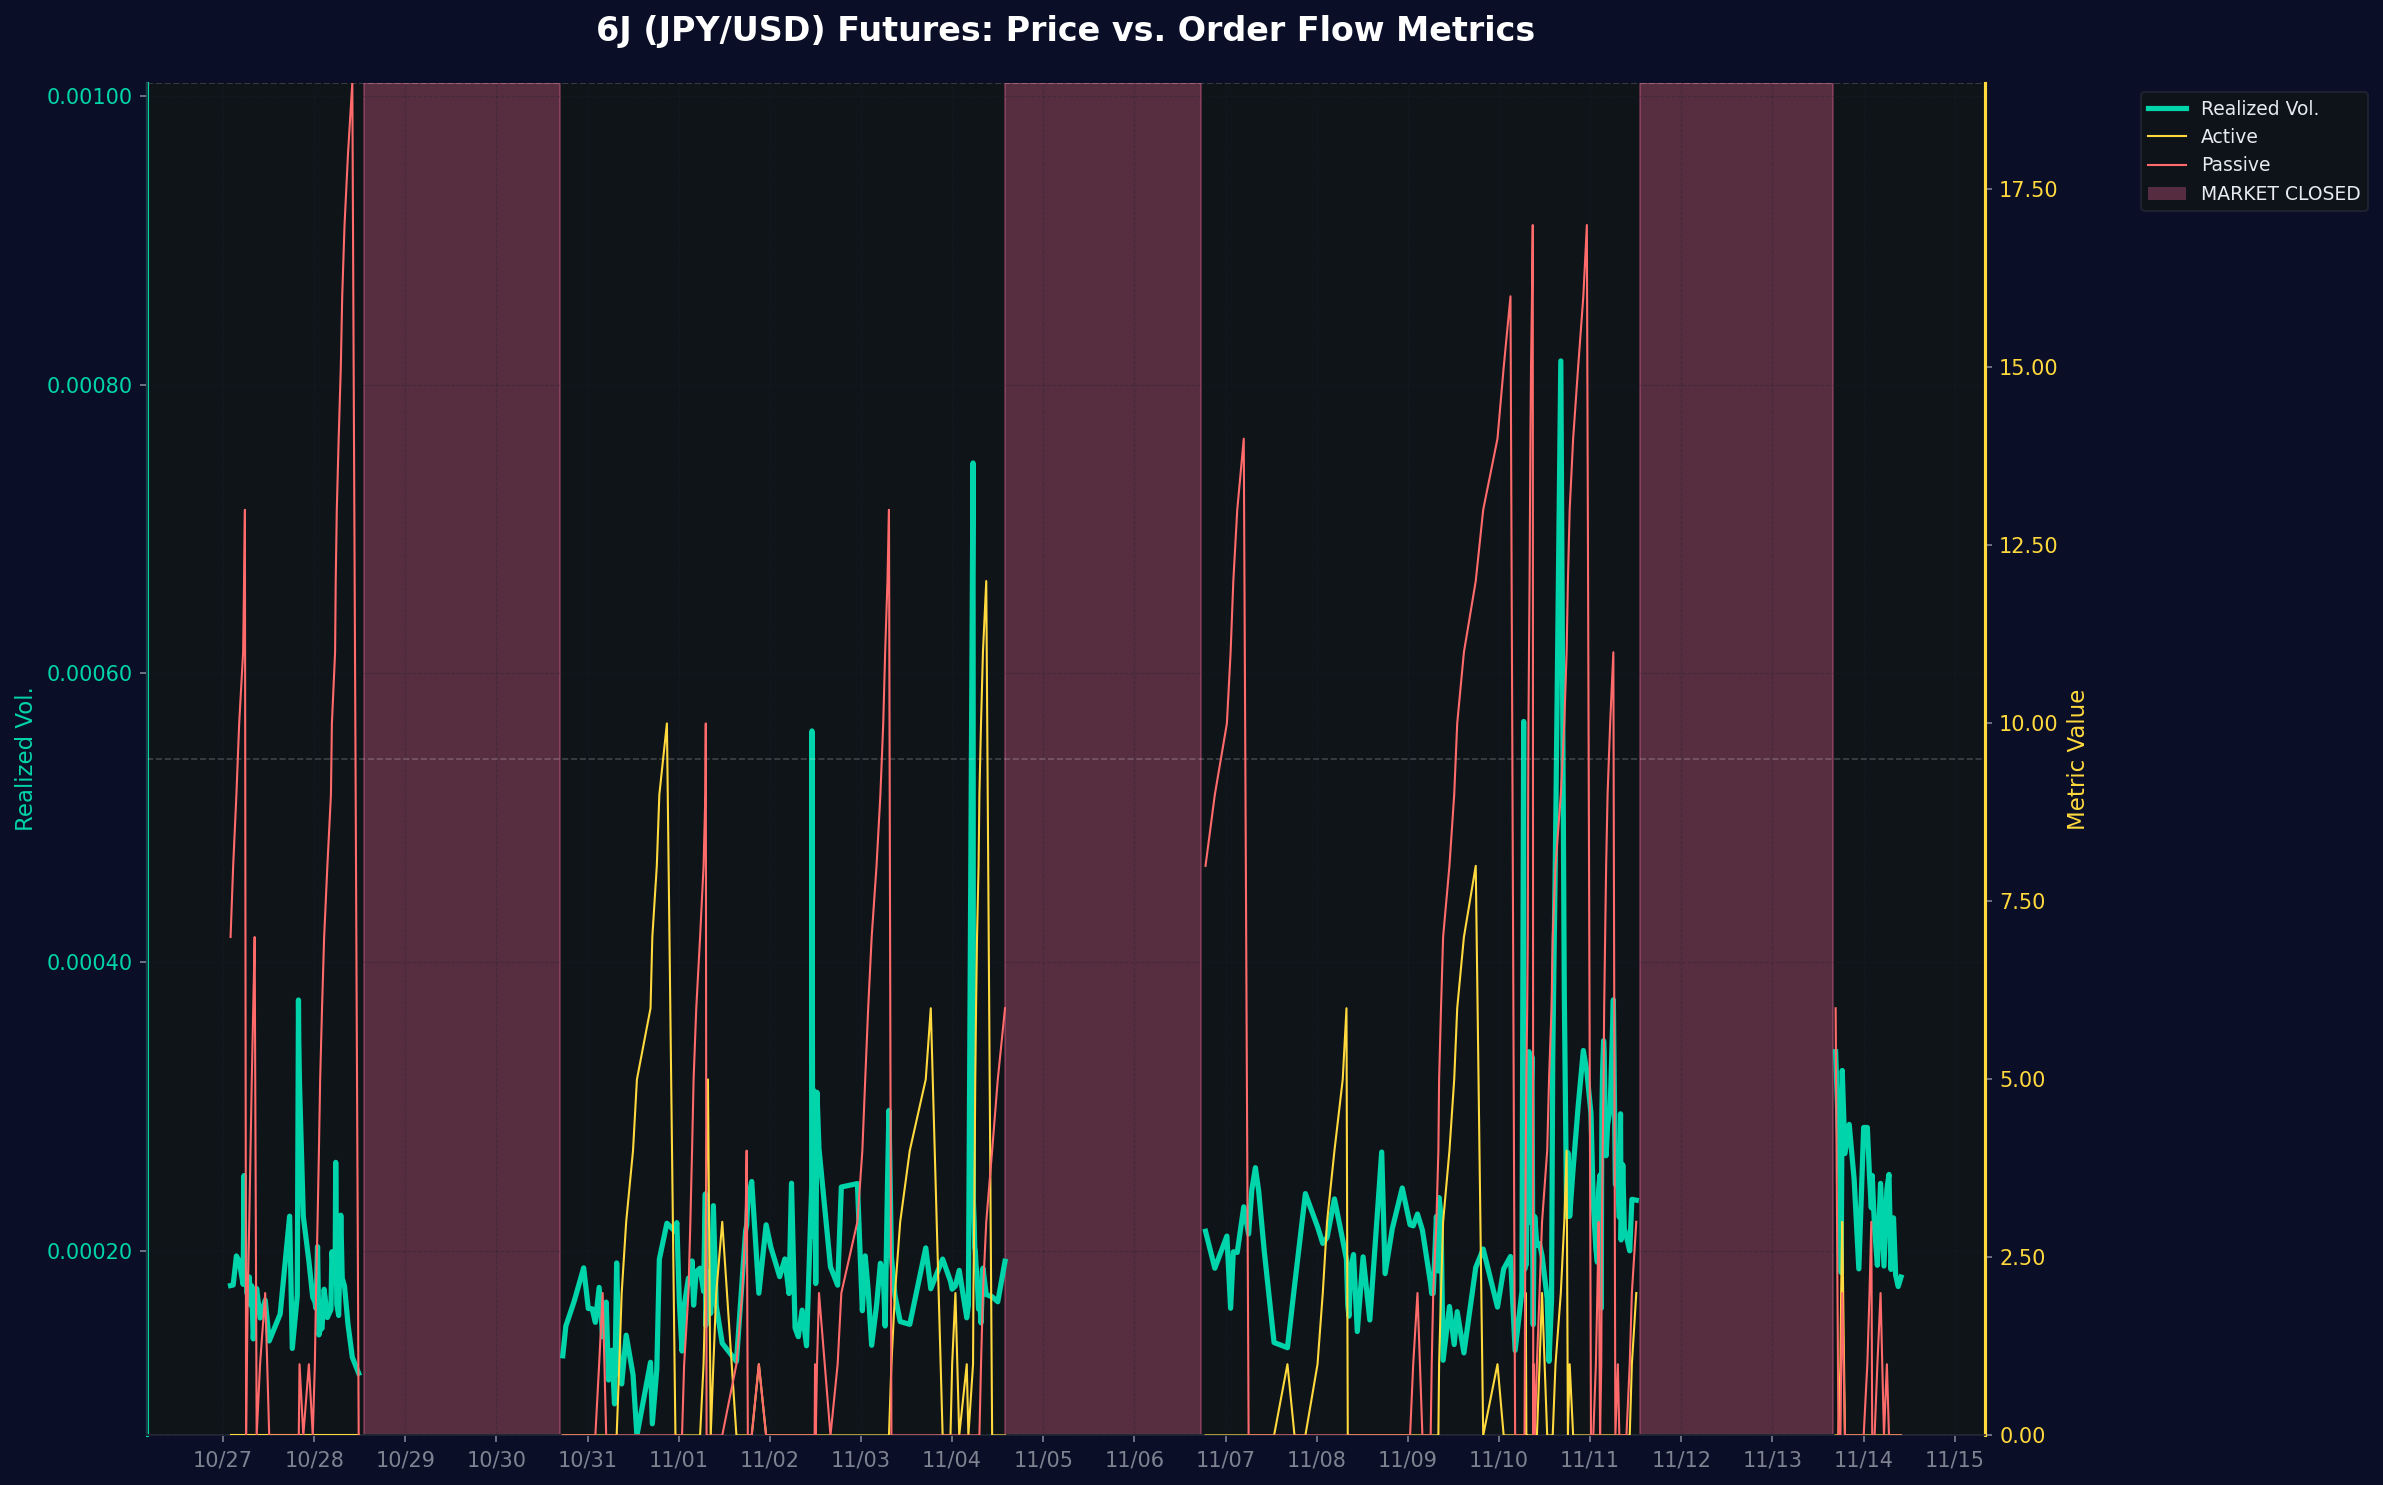

In [13]:
fig, (ax_price, ax_metrics) = plot_price_with_metrics(

    main_df=rolling_metrics_event,
    main_ts_col="end_ts_ns",
    main_col="delta_passive_midprice_log_std", #"passive_midprice",
    main_decimal_places=5,

    metrics_df=rolling_metrics_event,
    metrics_ts_col="end_ts_ns",
    metric_cols=["streak__ecdf__normalized__active_imbalance_abs_above_08", "streak__ecdf__normalized__passive_imbalance_abs_above_08"],
    metric_labels=["Active", "Passive"],
    # metric_range=(0, 1),

    title="6J (JPY/USD) Futures: Price vs. Order Flow Metrics",
    main_label="Realized Vol.",


    event_a_col="contract_roll_any",
    event_a_label="CONTRACT ROLL",

    event_b_col="gap_return_any",
    event_b_label="MARKET CLOSED",

    show_calculation_guides=False,
    step_lines=False,
)
plt.show()

figure out how to implement some quick regressions



In [14]:

def regression_summary(df: pl.DataFrame, x_col: str, y_col: str) -> dict:
    """
    Calculate full regression statistics for Y ~ X
    Returns comprehensive summary including coefficients, standard errors, 
    t-statistics, p-values, and confidence intervals
    """
    # Extract data
    X = df[x_col].to_numpy()
    Y = df[y_col].to_numpy()
    n = len(X)
    
    # Remove any null values
    mask = ~(np.isnan(X) | np.isnan(Y))
    X = X[mask]
    Y = Y[mask]
    n = len(X)
    
    # Design matrix with intercept
    X_design = np.column_stack([np.ones(n), X])
    
    # Estimate coefficients: β = (X'X)^-1 X'Y
    XtX_inv = np.linalg.inv(X_design.T @ X_design)
    beta = XtX_inv @ X_design.T @ Y
    
    # Predictions and residuals
    Y_pred = X_design @ beta
    residuals = Y - Y_pred
    
    # Sum of squares
    SS_total = np.sum((Y - Y.mean())**2)
    SS_residual = np.sum(residuals**2)
    SS_regression = SS_total - SS_residual
    
    # Degrees of freedom
    df_model = 1  # one predictor
    df_residual = n - 2
    df_total = n - 1
    
    # Mean squared error and R-squared
    MSE = SS_residual / df_residual
    R_squared = SS_regression / SS_total
    R_squared_adj = 1 - (1 - R_squared) * (df_total / df_residual)
    
    # Standard errors of coefficients
    se_beta = np.sqrt(np.diag(XtX_inv) * MSE)
    
    # T-statistics and p-values
    t_stats = beta / se_beta
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df_residual))
    
    # 95% confidence intervals
    t_crit = stats.t.ppf(0.975, df_residual)
    ci_lower = beta - t_crit * se_beta
    ci_upper = beta + t_crit * se_beta
    
    # F-statistic for overall model
    F_stat = (SS_regression / df_model) / MSE
    F_pvalue = 1 - stats.f.cdf(F_stat, df_model, df_residual)
    
    # Root MSE and correlation
    RMSE = np.sqrt(MSE)
    correlation = np.corrcoef(X, Y)[0, 1]
    
    return {
        'n_observations': n,
        'intercept': beta[0],
        'slope': beta[1],
        'se_intercept': se_beta[0],
        'se_slope': se_beta[1],
        't_intercept': t_stats[0],
        't_slope': t_stats[1],
        'p_intercept': p_values[0],
        'p_slope': p_values[1],
        'ci_intercept_lower': ci_lower[0],
        'ci_intercept_upper': ci_upper[0],
        'ci_slope_lower': ci_lower[1],
        'ci_slope_upper': ci_upper[1],
        'r_squared': R_squared,
        'r_squared_adj': R_squared_adj,
        'rmse': RMSE,
        'correlation': correlation,
        'f_statistic': F_stat,
        'f_pvalue': F_pvalue,
        'SS_regression': SS_regression,
        'SS_residual': SS_residual,
        'SS_total': SS_total
    }


In [15]:

def print_regression_summary(results: dict, x_name: str, y_name: str):
    """
    Print formatted regression summary similar to R or statsmodels output
    """
    print("=" * 80)
    print(f"LINEAR REGRESSION SUMMARY: {y_name} ~ {x_name}")
    print("=" * 80)
    print(f"\nNumber of observations: {results['n_observations']}")
    print(f"R-squared: {results['r_squared']:.4f}")
    print(f"Adjusted R-squared: {results['r_squared_adj']:.4f}")
    print(f"Root MSE: {results['rmse']:.4f}")
    print(f"Correlation: {results['correlation']:.4f}")
    
    print("\n" + "-" * 80)
    print("OVERALL MODEL FIT")
    print("-" * 80)
    print(f"F-statistic: {results['f_statistic']:.4f}")
    print(f"P-value: {results['f_pvalue']:.6f}")
    if results['f_pvalue'] < 0.001:
        print("Significance: *** (p < 0.001)")
    elif results['f_pvalue'] < 0.01:
        print("Significance: ** (p < 0.01)")
    elif results['f_pvalue'] < 0.05:
        print("Significance: * (p < 0.05)")
    else:
        print("Significance: Not significant (p >= 0.05)")
    
    print("\n" + "-" * 80)
    print("COEFFICIENT ESTIMATES")
    print("-" * 80)
    print(f"{'Variable':<15} {'Coef':<12} {'Std Err':<12} {'t':<10} {'P>|t|':<12} {'[0.025':<12} {'0.975]':<12}")
    print("-" * 80)
    
    # Intercept row
    sig_intercept = '***' if results['p_intercept'] < 0.001 else '**' if results['p_intercept'] < 0.01 else '*' if results['p_intercept'] < 0.05 else ''
    print(f"{'Intercept':<15} {results['intercept']:<12.4f} {results['se_intercept']:<12.4f} "
          f"{results['t_intercept']:<10.3f} {results['p_intercept']:<12.6f} "
          f"{results['ci_intercept_lower']:<12.4f} {results['ci_intercept_upper']:<12.4f} {sig_intercept}")
    
    # Slope row
    sig_slope = '***' if results['p_slope'] < 0.001 else '**' if results['p_slope'] < 0.01 else '*' if results['p_slope'] < 0.05 else ''
    print(f"{x_name:<15} {results['slope']:<12.4f} {results['se_slope']:<12.4f} "
          f"{results['t_slope']:<10.3f} {results['p_slope']:<12.6f} "
          f"{results['ci_slope_lower']:<12.4f} {results['ci_slope_upper']:<12.4f} {sig_slope}")
    
    print("-" * 80)
    print("Significance codes: *** p<0.001, ** p<0.01, * p<0.05")
    
    print("\n" + "-" * 80)
    print("INTERPRETATION: EFFECT OF X ON Y")
    print("-" * 80)
    print(f"For each 1-unit increase in {x_name}:")
    print(f"  - {y_name} changes by {results['slope']:.4f} units")
    print(f"  - 95% CI: [{results['ci_slope_lower']:.4f}, {results['ci_slope_upper']:.4f}]")
    
    if results['p_slope'] < 0.05:
        direction = "increases" if results['slope'] > 0 else "decreases"
        print(f"\nThe effect is statistically significant (p = {results['p_slope']:.6f})")
        print(f"{x_name} significantly {direction} {y_name}")
    else:
        print(f"\nThe effect is NOT statistically significant (p = {results['p_slope']:.6f})")
        print(f"Insufficient evidence that {x_name} affects {y_name}")
    
    print("\n" + "=" * 80)


In [23]:
# Run regression and print summary
results = regression_summary(rolling_metric.collect(), "streak__ecdf__normalized__passive_imbalance_abs_above_08", "delta_passive_midprice_log_std")
print_regression_summary(results, "streak__ecdf__passive__active_imbalance_abs_above_08", "Realized_Vol")

# Access specific values
print(f"Slope: {results['slope']:.4f}")
print(f"P-value: {results['p_slope']:.6f}")
print(f"95% CI: [{results['ci_slope_lower']:.4f}, {results['ci_slope_upper']:.4f}]")

LINEAR REGRESSION SUMMARY: Realized_Vol ~ streak__ecdf__passive__active_imbalance_abs_above_08

Number of observations: 18297
R-squared: 0.0802
Adjusted R-squared: 0.0801
Root MSE: 0.0001
Correlation: 0.2832

--------------------------------------------------------------------------------
OVERALL MODEL FIT
--------------------------------------------------------------------------------
F-statistic: 1594.6951
P-value: 0.000000
Significance: *** (p < 0.001)

--------------------------------------------------------------------------------
COEFFICIENT ESTIMATES
--------------------------------------------------------------------------------
Variable        Coef         Std Err      t          P>|t|        [0.025       0.975]      
--------------------------------------------------------------------------------
Intercept       0.0002       0.0000       228.639    0.000000     0.0002       0.0002       ***
streak__ecdf__passive__active_imbalance_abs_above_08 0.0000       0.0000       39.934 

In [25]:


def plot_regression_diagnostics(df: pl.DataFrame, x_col: str, y_col: str, results: dict):
    """
    Create comprehensive diagnostic plots for regression analysis
    """
    # Extract data
    X = df[x_col].to_numpy()
    Y = df[y_col].to_numpy()
    
    # Remove nulls
    mask = ~(np.isnan(X) | np.isnan(Y))
    X = X[mask]
    Y = Y[mask]
    
    # Calculate fitted values and residuals
    Y_pred = results['intercept'] + results['slope'] * X
    residuals = Y - Y_pred
    standardized_residuals = residuals / results['rmse']
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(f'Regression Diagnostics: {y_col} ~ {x_col}', fontsize=16, fontweight='bold')
    
    # 1. Scatter plot with regression line
    ax1 = axes[0, 0]
    ax1.scatter(X, Y, alpha=0.5, s=30, edgecolors='black', linewidth=0.5)
    
    # Sort for smooth line
    X_sorted = np.sort(X)
    Y_fitted_sorted = results['intercept'] + results['slope'] * X_sorted
    ax1.plot(X_sorted, Y_fitted_sorted, 'r-', linewidth=2, label='Fitted Line')
    
    # Confidence interval for mean response
    X_mean = X.mean()
    n = len(X)
    t_crit = stats.t.ppf(0.975, n - 2)
    se_fit = results['rmse'] * np.sqrt(1/n + (X_sorted - X_mean)**2 / np.sum((X - X_mean)**2))
    ci_upper = Y_fitted_sorted + t_crit * se_fit
    ci_lower = Y_fitted_sorted - t_crit * se_fit
    ax1.fill_between(X_sorted, ci_lower, ci_upper, alpha=0.2, color='red', label='95% CI')
    
    ax1.set_xlabel(x_col, fontsize=11)
    ax1.set_ylabel(y_col, fontsize=11)
    ax1.set_title('Fitted Regression Line', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Add R² text
    ax1.text(0.05, 0.95, f'R² = {results["r_squared"]:.4f}\nSlope = {results["slope"]:.4f}',
             transform=ax1.transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # 2. Residuals vs Fitted Values
    ax2 = axes[0, 1]
    ax2.scatter(Y_pred, residuals, alpha=0.5, s=30, edgecolors='black', linewidth=0.5)
    ax2.axhline(y=0, color='r', linestyle='--', linewidth=2)
    ax2.set_xlabel('Fitted Values', fontsize=11)
    ax2.set_ylabel('Residuals', fontsize=11)
    ax2.set_title('Residuals vs Fitted', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # Add lowess smoothing line to detect patterns
    try:
        from scipy.signal import savgol_filter
        sorted_idx = np.argsort(Y_pred)
        smoothed = savgol_filter(residuals[sorted_idx], min(51, len(residuals)//3*2+1), 3)
        ax2.plot(Y_pred[sorted_idx], smoothed, 'b-', linewidth=2, alpha=0.7)
    except:
        pass
    
    # 3. Q-Q Plot (Normal Probability Plot)
    ax3 = axes[0, 2]
    stats.probplot(standardized_residuals, dist="norm", plot=ax3)
    ax3.set_title('Normal Q-Q Plot', fontsize=12, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    
    # 4. Scale-Location Plot (Sqrt of Standardized Residuals vs Fitted)
    ax4 = axes[1, 0]
    sqrt_abs_residuals = np.sqrt(np.abs(standardized_residuals))
    ax4.scatter(Y_pred, sqrt_abs_residuals, alpha=0.5, s=30, edgecolors='black', linewidth=0.5)
    ax4.set_xlabel('Fitted Values', fontsize=11)
    ax4.set_ylabel('√|Standardized Residuals|', fontsize=11)
    ax4.set_title('Scale-Location Plot', fontsize=12, fontweight='bold')
    ax4.grid(True, alpha=0.3)
    
    # 5. Residual Histogram
    ax5 = axes[1, 1]
    ax5.hist(standardized_residuals, bins=30, edgecolor='black', alpha=0.7)
    ax5.axvline(x=0, color='r', linestyle='--', linewidth=2)
    ax5.set_xlabel('Standardized Residuals', fontsize=11)
    ax5.set_ylabel('Frequency', fontsize=11)
    ax5.set_title('Residual Distribution', fontsize=12, fontweight='bold')
    ax5.grid(True, alpha=0.3, axis='y')
    
    # Add normal curve overlay
    mu, sigma = 0, 1
    x_range = np.linspace(standardized_residuals.min(), standardized_residuals.max(), 100)
    ax5_twin = ax5.twinx()
    ax5_twin.plot(x_range, stats.norm.pdf(x_range, mu, sigma) * len(residuals) * 
                  (standardized_residuals.max() - standardized_residuals.min()) / 30,
                  'r-', linewidth=2, label='Normal')
    ax5_twin.set_ylabel('Density', fontsize=11)
    
    # 6. Actual vs Predicted
    ax6 = axes[1, 2]
    ax6.scatter(Y, Y_pred, alpha=0.5, s=30, edgecolors='black', linewidth=0.5)
    
    # Perfect prediction line
    min_val = min(Y.min(), Y_pred.min())
    max_val = max(Y.max(), Y_pred.max())
    ax6.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Fit')
    
    ax6.set_xlabel(f'Actual {y_col}', fontsize=11)
    ax6.set_ylabel(f'Predicted {y_col}', fontsize=11)
    ax6.set_title('Actual vs Predicted', fontsize=12, fontweight='bold')
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    
    # Add metrics
    mae = np.mean(np.abs(residuals))
    mape = np.mean(np.abs(residuals / Y)) * 100
    ax6.text(0.05, 0.95, f'MAE = {mae:.4f}\nMAPE = {mape:.2f}%\nRMSE = {results["rmse"]:.4f}',
             transform=ax6.transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    return fig



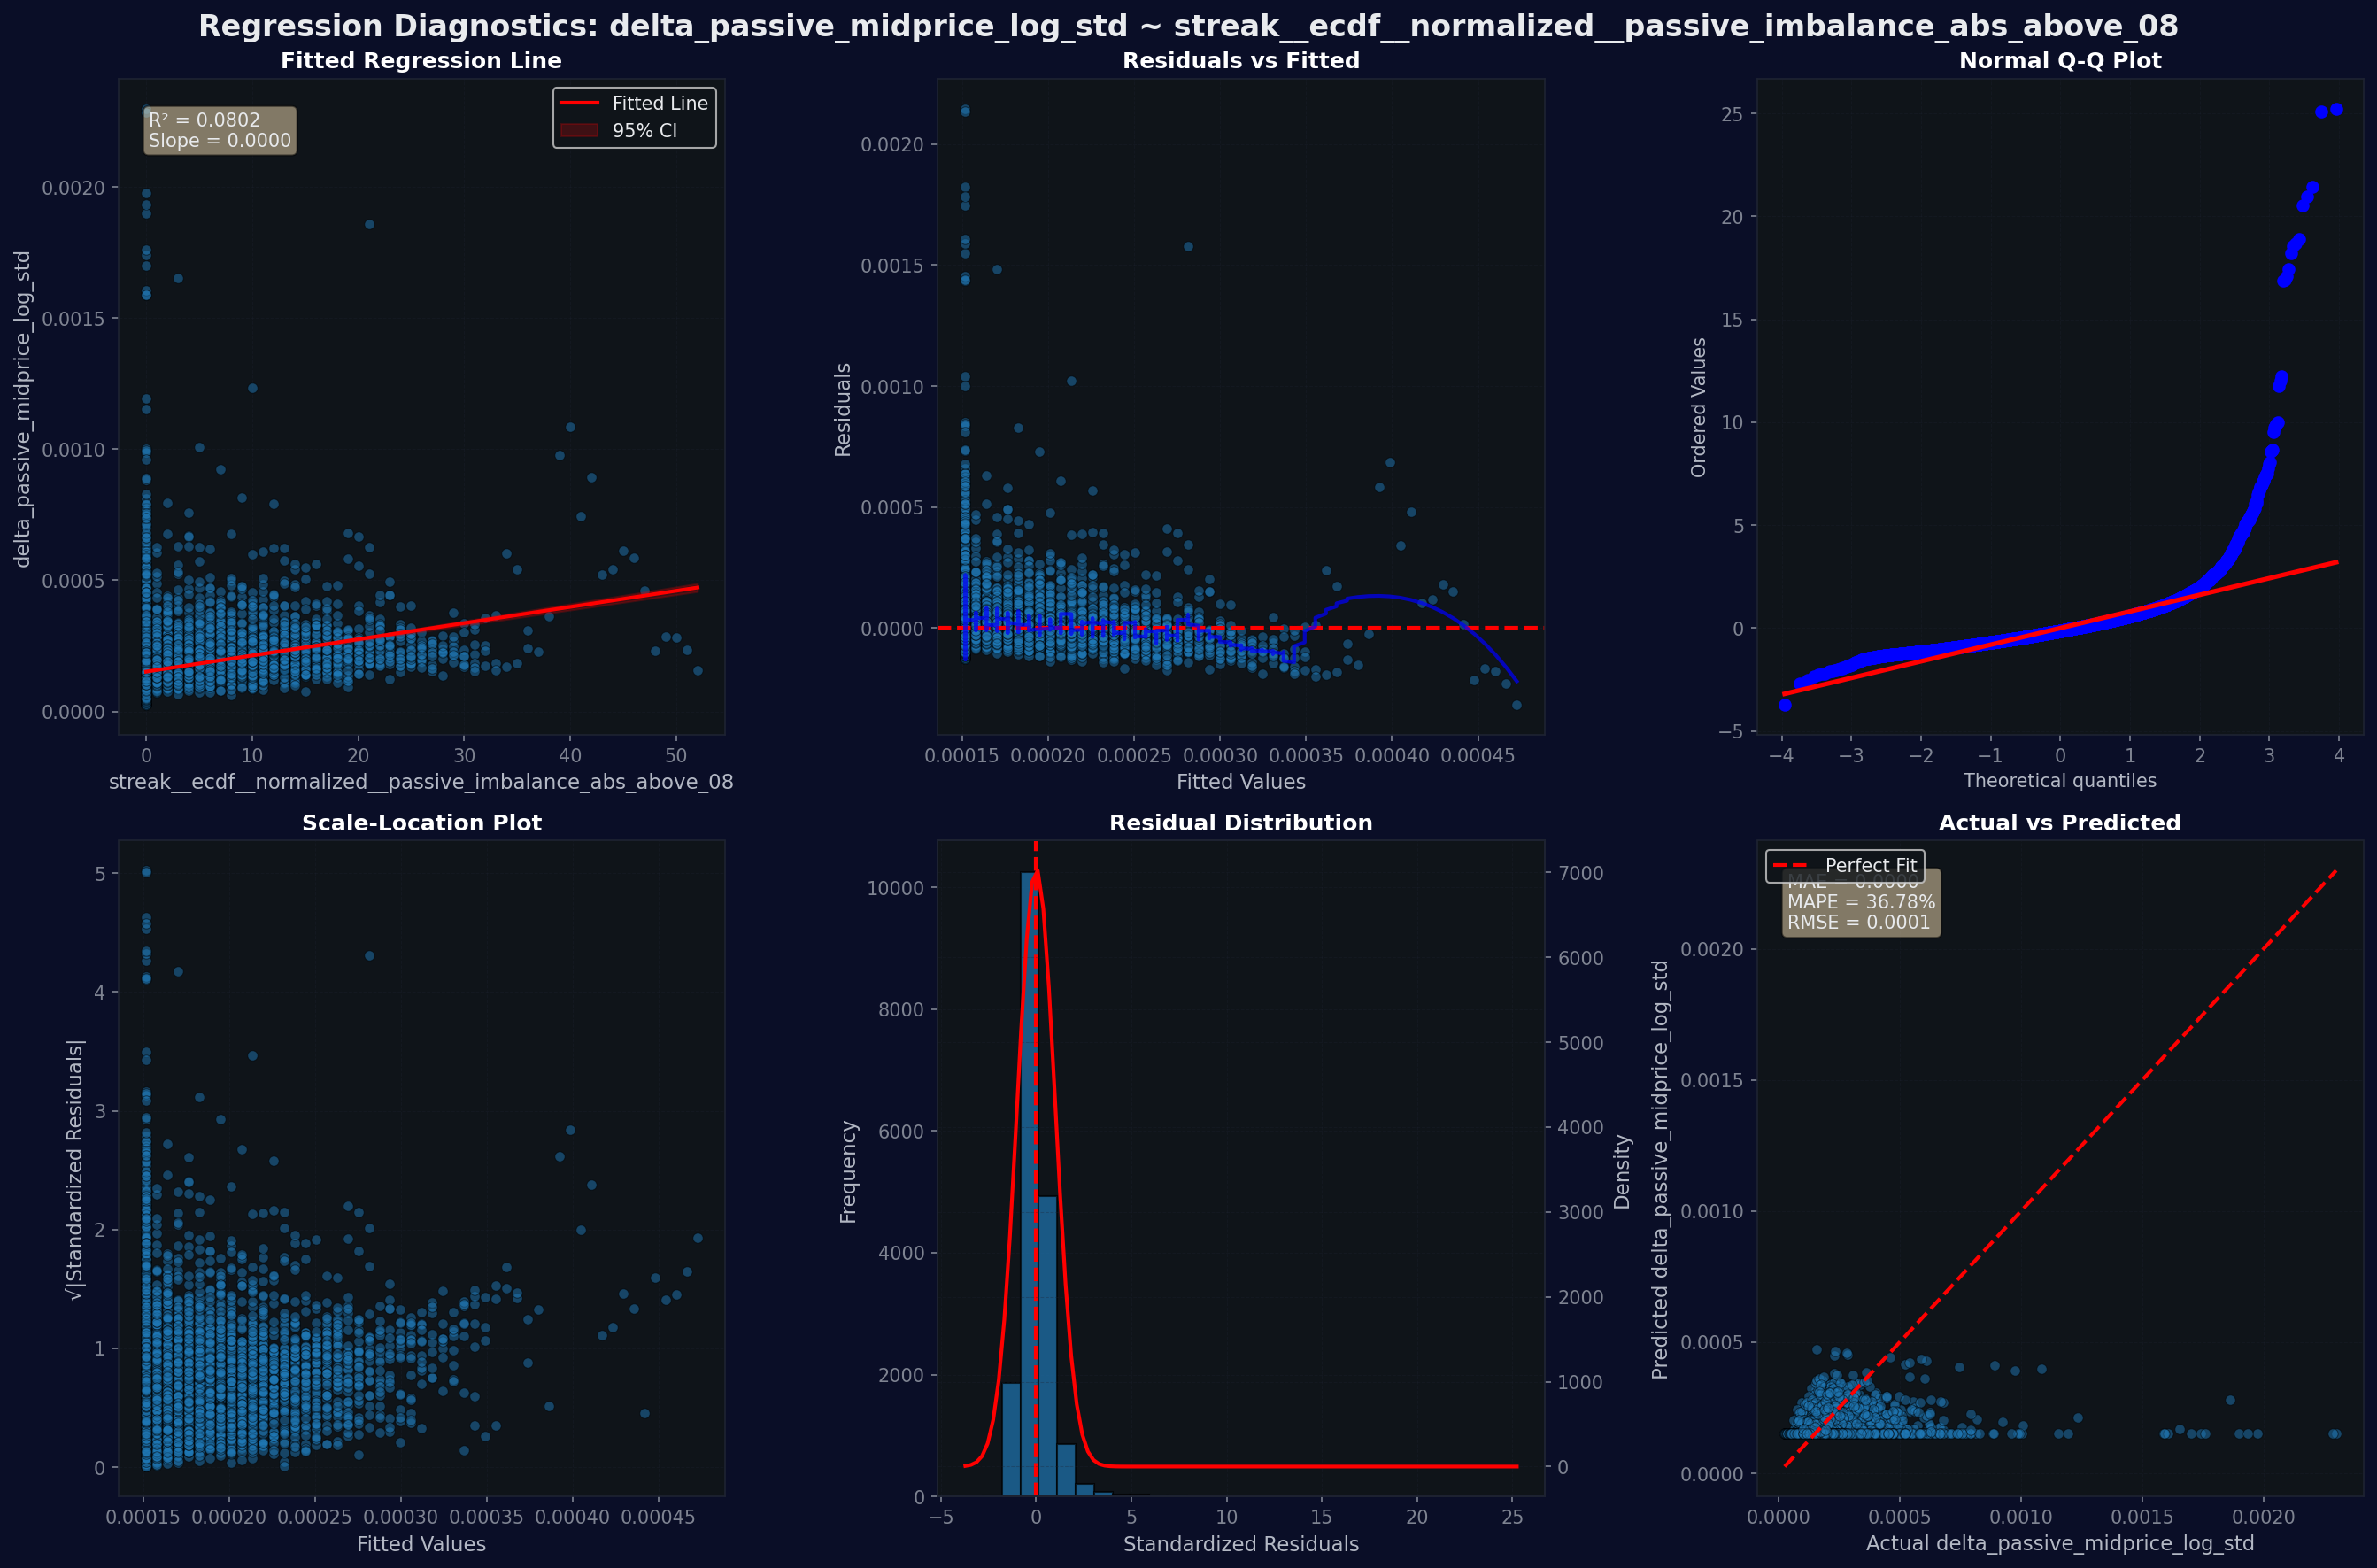

In [27]:
# Run regression and print summary
results = regression_summary(rolling_metric.collect(), "streak__ecdf__normalized__passive_imbalance_abs_above_08", "delta_passive_midprice_log_std")
fig = plot_regression_diagnostics(rolling_metric.collect(), "streak__ecdf__normalized__passive_imbalance_abs_above_08", "delta_passive_midprice_log_std", results)
plt.show()

In [28]:
def plot_simple_fit(df: pl.DataFrame, x_col: str, y_col: str, results: dict):
    """
    Simple visualization of regression fit
    """
    X = df[x_col].to_numpy()
    Y = df[y_col].to_numpy()
    
    mask = ~(np.isnan(X) | np.isnan(Y))
    X = X[mask]
    Y = Y[mask]
    
    Y_pred = results['intercept'] + results['slope'] * X
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Scatter plot
    ax.scatter(X, Y, alpha=0.6, s=50, edgecolors='black', linewidth=0.5, label='Data')
    
    # Regression line
    X_sorted = np.sort(X)
    Y_fitted = results['intercept'] + results['slope'] * X_sorted
    ax.plot(X_sorted, Y_fitted, 'r-', linewidth=2.5, label='Fitted Line')
    
    # Confidence band
    X_mean = X.mean()
    n = len(X)
    t_crit = stats.t.ppf(0.975, n - 2)
    se_fit = results['rmse'] * np.sqrt(1/n + (X_sorted - X_mean)**2 / np.sum((X - X_mean)**2))
    ci_upper = Y_fitted + t_crit * se_fit
    ci_lower = Y_fitted - t_crit * se_fit
    ax.fill_between(X_sorted, ci_lower, ci_upper, alpha=0.2, color='red', label='95% CI')
    
    # Labels and title
    ax.set_xlabel(x_col, fontsize=12)
    ax.set_ylabel(y_col, fontsize=12)
    ax.set_title(f'Regression: {y_col} ~ {x_col}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Add statistics box
    stats_text = f'Slope: {results["slope"]:.4f} [{results["ci_slope_lower"]:.4f}, {results["ci_slope_upper"]:.4f}]\n'
    stats_text += f'R²: {results["r_squared"]:.4f}\n'
    stats_text += f'P-value: {results["p_slope"]:.6f}\n'
    stats_text += f'RMSE: {results["rmse"]:.4f}'
    
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
            verticalalignment='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    return fig

# Usage
# fig = plot_simple_fit(df, 'X', 'Y', results)
# plt.show()

In [29]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def plot_interactive_fit(df: pl.DataFrame, x_col: str, y_col: str, results: dict):
    """
    Interactive regression diagnostics with plotly
    """
    X = df[x_col].to_numpy()
    Y = df[y_col].to_numpy()
    
    mask = ~(np.isnan(X) | np.isnan(Y))
    X = X[mask]
    Y = Y[mask]
    
    Y_pred = results['intercept'] + results['slope'] * X
    residuals = Y - Y_pred
    
    # Create subplots
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=('Regression Fit', 'Residuals vs Fitted',
                       'Actual vs Predicted', 'Residual Distribution'),
        specs=[[{"type": "scatter"}, {"type": "scatter"}],
               [{"type": "scatter"}, {"type": "histogram"}]]
    )
    
    # 1. Regression fit
    X_sorted = np.sort(X)
    Y_fitted = results['intercept'] + results['slope'] * X_sorted
    
    fig.add_trace(go.Scatter(x=X, y=Y, mode='markers', name='Data',
                            marker=dict(size=6, opacity=0.6)), row=1, col=1)
    fig.add_trace(go.Scatter(x=X_sorted, y=Y_fitted, mode='lines',
                            name='Fit', line=dict(color='red', width=2)), row=1, col=1)
    
    # 2. Residuals
    fig.add_trace(go.Scatter(x=Y_pred, y=residuals, mode='markers',
                            name='Residuals', marker=dict(size=6, opacity=0.6),
                            showlegend=False), row=1, col=2)
    fig.add_hline(y=0, line_dash="dash", line_color="red", row=1, col=2)
    
    # 3. Actual vs Predicted
    fig.add_trace(go.Scatter(x=Y, y=Y_pred, mode='markers',
                            name='Predictions', marker=dict(size=6, opacity=0.6),
                            showlegend=False), row=2, col=1)
    min_val = min(Y.min(), Y_pred.min())
    max_val = max(Y.max(), Y_pred.max())
    fig.add_trace(go.Scatter(x=[min_val, max_val], y=[min_val, max_val],
                            mode='lines', name='Perfect', 
                            line=dict(dash='dash', color='red')), row=2, col=1)
    
    # 4. Histogram
    fig.add_trace(go.Histogram(x=residuals, name='Residuals',
                              marker=dict(opacity=0.7), showlegend=False), row=2, col=2)
    
    # Update layout
    fig.update_xaxes(title_text=x_col, row=1, col=1)
    fig.update_yaxes(title_text=y_col, row=1, col=1)
    fig.update_xaxes(title_text="Fitted", row=1, col=2)
    fig.update_yaxes(title_text="Residuals", row=1, col=2)
    fig.update_xaxes(title_text="Actual", row=2, col=1)
    fig.update_yaxes(title_text="Predicted", row=2, col=1)
    fig.update_xaxes(title_text="Residuals", row=2, col=2)
    
    fig.update_layout(height=800, width=1200, 
                     title_text=f"Regression Diagnostics: {y_col} ~ {x_col}")
    
    return fig

# Usage
# fig = plot_interactive_fit(df, 'X', 'Y', results)
# fig.show()

In [ ]:
def multiple_regression_summary(df: pl.DataFrame, y_col: str, x_cols: list[str]) -> dict:
    """
    Multiple regression: Y ~ X1 + X2 + ... + Xk
    """
    # Extract data
    Y = df[y_col].to_numpy()
    X_list = [df[col].to_numpy() for col in x_cols]
    
    # Remove nulls
    mask = ~np.isnan(Y)
    for x in X_list:
        mask &= ~np.isnan(x)
    
    Y = Y[mask]
    X_data = np.column_stack([x[mask] for x in X_list])
    n = len(Y)
    k = len(x_cols)
    
    # Design matrix with intercept
    X_design = np.column_stack([np.ones(n), X_data])
    
    # Coefficients
    XtX_inv = np.linalg.inv(X_design.T @ X_design)
    beta = XtX_inv @ X_design.T @ Y
    
    # Statistics
    Y_pred = X_design @ beta
    residuals = Y - Y_pred
    
    SS_total = np.sum((Y - Y.mean())**2)
    SS_residual = np.sum(residuals**2)
    SS_regression = SS_total - SS_residual
    
    df_model = k
    df_residual = n - k - 1
    
    MSE = SS_residual / df_residual
    R_squared = SS_regression / SS_total
    R_squared_adj = 1 - (1 - R_squared) * ((n - 1) / df_residual)
    
    se_beta = np.sqrt(np.diag(XtX_inv) * MSE)
    t_stats = beta / se_beta
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df_residual))
    
    t_crit = stats.t.ppf(0.975, df_residual)
    ci_lower = beta - t_crit * se_beta
    ci_upper = beta + t_crit * se_beta
    
    F_stat = (SS_regression / df_model) / MSE
    F_pvalue = 1 - stats.f.cdf(F_stat, df_model, df_residual)
    
    return {
        'n_observations': n,
        'coefficients': beta,
        'se_coefficients': se_beta,
        't_statistics': t_stats,
        'p_values': p_values,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'variable_names': ['Intercept'] + x_cols,
        'r_squared': R_squared,
        'r_squared_adj': R_squared_adj,
        'rmse': np.sqrt(MSE),
        'f_statistic': F_stat,
        'f_pvalue': F_pvalue
    }